# DATA 255 Lab 1: Custom CNN Image Classification (20 classes)


## 1. Mount Google Drive and unzip the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
DRIVE_FOLDER = "/content/drive/MyDrive/DATA255_Lab"
os.makedirs("/content/data", exist_ok=True)

with zipfile.ZipFile(f"{DRIVE_FOLDER}/imagenet_train20.zip", 'r') as z:
    z.extractall("/content/data")
with zipfile.ZipFile(f"{DRIVE_FOLDER}/imagenet_val20.zip", 'r') as z:
    z.extractall("/content/data")

print("Train images:", sum(len(files) for _, _, files in os.walk("/content/data/imagenet_train20a")))
print("Val images:", sum(len(files) for _, _, files in os.walk("/content/data/imagenet_val20")))


Mounted at /content/drive
Train images: 6000
Val images: 1000


## 2. Dataset, transforms, DataLoaders, and model architecture


In [2]:
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageNet20Dataset(Dataset):
    def __init__(self, txt_file, img_root, transform=None):
        with open(txt_file) as f:
            self.samples = [l.strip().split() for l in f if l.strip()]
        self.filepath_lookup = {}
        for root, dirs, files in os.walk(img_root):
            for fname in files:
                self.filepath_lookup[fname] = os.path.join(root, fname)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        image = Image.open(self.filepath_lookup[fname]).convert("RGB")
        label = int(label)
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomCrop((240, 240)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageNet20Dataset(f"{DRIVE_FOLDER}/imagenet_train20.txt", "/content/data/imagenet_train20a", train_transform)
val_dataset = ImageNet20Dataset(f"{DRIVE_FOLDER}/imagenet_val20.txt", "/content/data/imagenet_val20", val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class CustomCNN(nn.Module):
    def __init__(self, num_classes=20):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5), nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.block4(x); x = self.block5(x); x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN(num_classes=20).to(device)
print("Using device:", device)
print("Total parameters:", sum(p.numel() for p in model.parameters()))


Using device: cuda
Total parameters: 1209652


## 3. Training loop


In [3]:
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
CHECKPOINT_PATH = f"{DRIVE_FOLDER}/best_model.pth"

def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate_one_epoch():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

NUM_EPOCHS = 46
history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch()
    val_acc = validate_one_epoch()
    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    is_best = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "epoch": epoch,
            "history": history
        }, CHECKPOINT_PATH)
        is_best = "  <-- saved to Drive"

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}% | "
          f"Time: {elapsed:.1f}s{is_best}")

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")


Epoch 1/46 | Train Loss: 2.7100 | Train Acc: 15.13% | Val Acc: 22.10% | Time: 72.4s  <-- saved to Drive
Epoch 2/46 | Train Loss: 2.5168 | Train Acc: 20.60% | Val Acc: 25.10% | Time: 65.1s  <-- saved to Drive
Epoch 3/46 | Train Loss: 2.3869 | Train Acc: 24.20% | Val Acc: 26.00% | Time: 62.6s  <-- saved to Drive
Epoch 4/46 | Train Loss: 2.3000 | Train Acc: 27.22% | Val Acc: 27.40% | Time: 61.3s  <-- saved to Drive
Epoch 5/46 | Train Loss: 2.2109 | Train Acc: 29.52% | Val Acc: 30.90% | Time: 61.7s  <-- saved to Drive
Epoch 6/46 | Train Loss: 2.1526 | Train Acc: 31.42% | Val Acc: 32.30% | Time: 62.0s  <-- saved to Drive
Epoch 7/46 | Train Loss: 2.0678 | Train Acc: 34.23% | Val Acc: 35.90% | Time: 63.5s  <-- saved to Drive
Epoch 8/46 | Train Loss: 1.9775 | Train Acc: 36.33% | Val Acc: 35.60% | Time: 62.0s
Epoch 9/46 | Train Loss: 1.9706 | Train Acc: 36.47% | Val Acc: 40.10% | Time: 62.2s  <-- saved to Drive
Epoch 10/46 | Train Loss: 1.8840 | Train Acc: 39.25% | Val Acc: 42.70% | Time: 62.6s

## 4. Load best checkpoint

In [4]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded model from epoch {checkpoint['epoch']} with val accuracy {checkpoint['val_acc']*100:.2f}%")


Loaded model from epoch 44 with val accuracy 71.40%


## 5. Build class name mapping (synset ID -> readable name)

In [5]:
synset_to_name = {
    "n02117135": "hyena", "n03935335": "piggy_bank", "n02013706": "limpkin",
    "n02676566": "acoustic_guitar", "n01737021": "water_snake", "n03804744": "nail",
    "n02808440": "bathtub", "n04252225": "snowplow", "n02423022": "gazelle",
    "n03721384": "marimba", "n03476684": "hair_slide", "n02006656": "spoonbill",
    "n04346328": "stupa", "n03016953": "chiffonier", "n02279972": "monarch_butterfly",
    "n02033041": "dowitcher", "n03938244": "pillow", "n02415577": "bighorn_sheep",
    "n02093991": "Irish_terrier", "n02011460": "bittern",
}
label_to_synset = {}
with open(f"{DRIVE_FOLDER}/imagenet_train20.txt") as f:
    for line in f:
        fname, label = line.strip().split()
        label_to_synset[int(label)] = fname.split("_")[0]
label_to_name = {label: synset_to_name[synset] for label, synset in label_to_synset.items()}
print("Class names loaded:", len(label_to_name))


Class names loaded: 20


## 6. Step 3 Analysis: per-class accuracy, precision/recall/F1, confusion matrix

Class               Precision   Recall    F1-score  
water_snake         0.57        0.84      0.68
spoonbill           0.77        0.88      0.82
bittern             0.69        0.62      0.65
limpkin             0.78        0.62      0.69
dowitcher           0.74        0.86      0.80
Irish_terrier       0.67        0.70      0.69
hyena               0.70        0.74      0.72
monarch_butterfly   0.96        0.98      0.97
bighorn_sheep       0.56        0.68      0.61
gazelle             0.76        0.52      0.62
acoustic_guitar     0.83        0.70      0.76
bathtub             0.71        0.58      0.64
chiffonier          0.96        0.96      0.96
hair_slide          0.70        0.62      0.66
marimba             0.53        0.64      0.58
nail                0.55        0.36      0.43
piggy_bank          0.61        0.62      0.61
pillow              0.74        0.58      0.65
snowplow            0.69        0.92      0.79
stupa               0.90        0.86      0.88


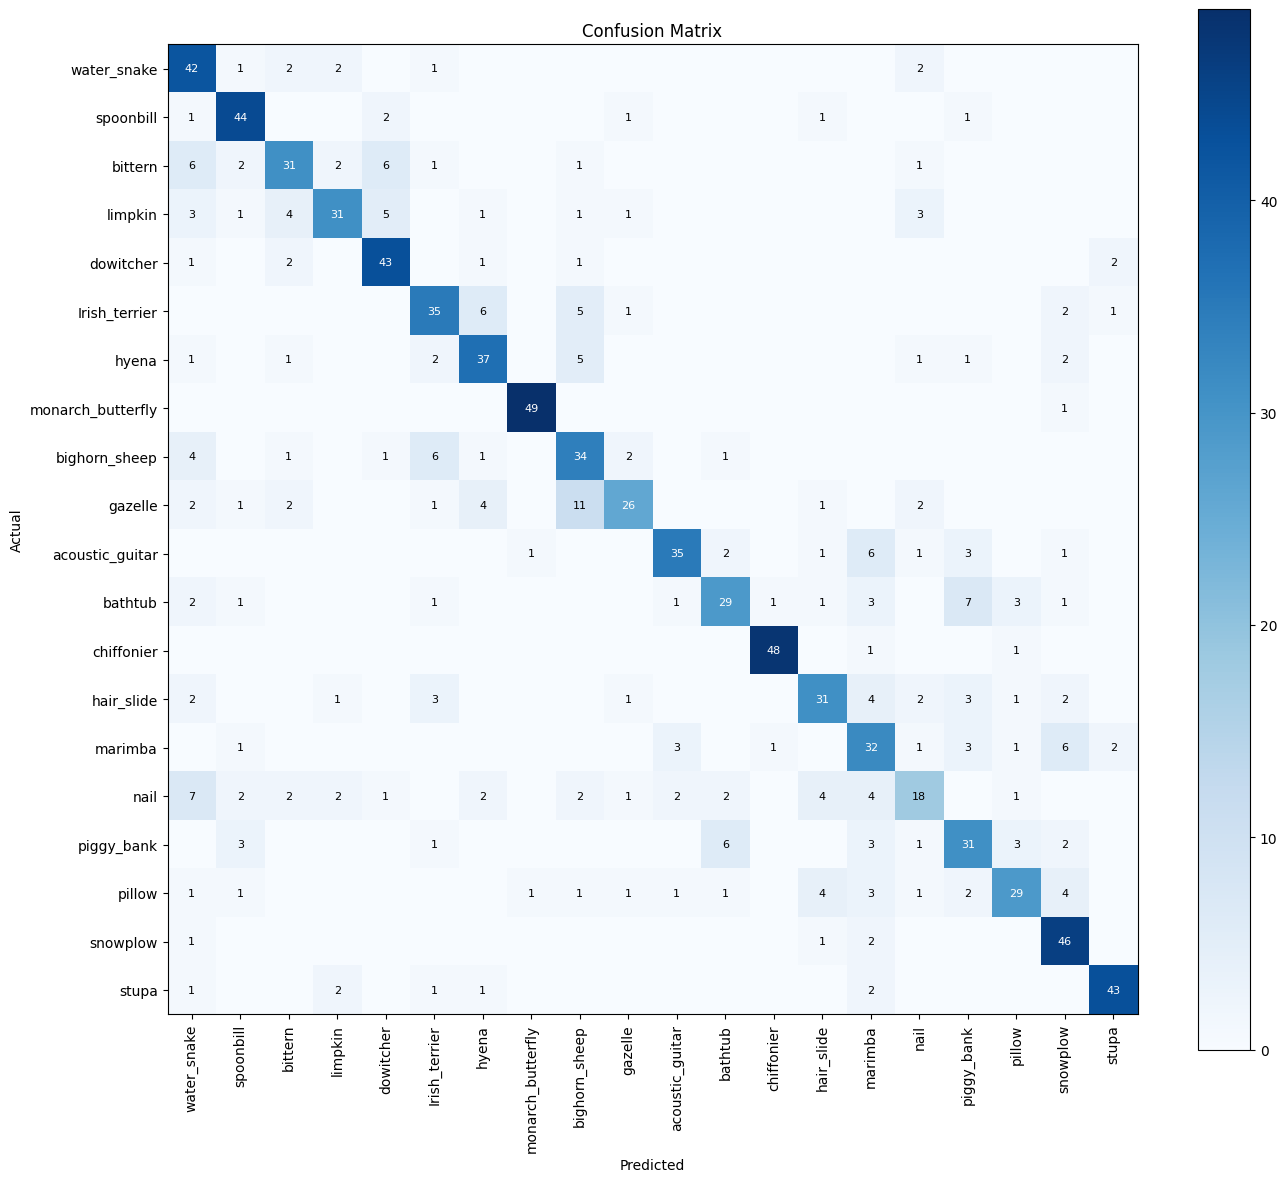


Saved confusion matrix image to Drive: /content/drive/MyDrive/DATA255_Lab/confusion_matrix.png


In [6]:
!pip install scikit-learn matplotlib -q

import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = [label_to_name[i] for i in range(20)]

cm = confusion_matrix(all_labels, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, zero_division=0)

print(f"{'Class':<20}{'Precision':<12}{'Recall':<10}{'F1-score':<10}")
for i in range(20):
    print(f"{class_names[i]:<20}{precision[i]:.2f}        {recall[i]:.2f}      {f1[i]:.2f}")

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(20), class_names, rotation=90)
plt.yticks(range(20), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
for i in range(20):
    for j in range(20):
        if cm[i, j] > 0:
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.savefig(f"{DRIVE_FOLDER}/confusion_matrix.png", dpi=150)
plt.show()

print(f"\nSaved confusion matrix image to Drive: {DRIVE_FOLDER}/confusion_matrix.png")


## 7. Export to ONNX (for NPU compilation)

In [7]:
!pip install onnx onnxscript -q

dummy_input = torch.randn(1, 3, 240, 240).to(device)
ONNX_PATH = f"{DRIVE_FOLDER}/custom_cnn.onnx"

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False
)

import os
size_mb = os.path.getsize(ONNX_PATH) / (1024*1024)
print(f"Model exported to: {ONNX_PATH}")
print(f"File size: {size_mb:.2f} MB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 16.9 MB/s eta 0:00:00


/tmp/ipykernel_1617/1551723674.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Model exported to: /content/drive/MyDrive/DATA255_Lab/custom_cnn.onnx
File size: 4.61 MB


## 8. Verify ONNX output matches PyTorch output

In [8]:
!pip install onnxruntime -q
import onnxruntime as ort
import numpy as np

ort_session = ort.InferenceSession(ONNX_PATH)

model.eval()
images, labels = next(iter(val_loader))
images_gpu = images.to(device)

with torch.no_grad():
    pytorch_output = model(images_gpu).cpu().numpy()

onnx_input = {"input": images.numpy()}
onnx_output = ort_session.run(None, onnx_input)[0]

max_diff = np.abs(pytorch_output - onnx_output).max()
print("Max difference between PyTorch and ONNX outputs:", max_diff)

pytorch_preds = pytorch_output.argmax(axis=1)
onnx_preds = onnx_output.argmax(axis=1)
agreement = (pytorch_preds == onnx_preds).mean()
print(f"Prediction agreement: {agreement*100:.1f}%")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 80.7 MB/s eta 0:00:00
Max difference between PyTorch and ONNX outputs: 7.6293945e-06
Prediction agreement: 100.0%


## 9. Build calibration data subset (for NPU quantization)


In [9]:
import random, shutil
from collections import defaultdict

CALIB_DIR = "/content/data/calibration"
os.makedirs(CALIB_DIR, exist_ok=True)
random.seed(42)
samples_per_class = 5

samples_by_class = defaultdict(list)
for fname, label in train_dataset.samples:
    samples_by_class[int(label)].append(fname)

calibration_files = []
for class_idx in range(20):
    chosen = random.sample(samples_by_class[class_idx], samples_per_class)
    for fname in chosen:
        src = train_dataset.filepath_lookup[fname]
        dst = os.path.join(CALIB_DIR, fname)
        shutil.copy(src, dst)
        calibration_files.append(fname)

print(f"Calibration set created: {len(calibration_files)} images")
shutil.make_archive(f"{DRIVE_FOLDER}/calibration_data", 'zip', CALIB_DIR)
print("Zipped and saved to Drive as calibration_data.zip")


Calibration set created: 100 images
Zipped and saved to Drive as calibration_data.zip


- Best PyTorch validation accuracy (checkpoint used for NPU deployment): **73.30%** (epoch 44). Note: the training log recorded 71.40% at the moment this checkpoint was saved; re-measuring the same saved weights afterward gave 73.30%. This small run-to-run gap is attributed to floating point / cuDNN nondeterminism rather than any change in the weights themselves.
- This checkpoint was exported to ONNX, verified for correctness, compiled to `.mxq` using Mobilint Qubee (with the calibration data built above), and run successfully on physical NPU hardware, achieving **74.20% accuracy** (742/1000) via the MACCEL runtime.